Best params: {'knn__metric': 'euclidean', 'knn__n_neighbors': np.int64(3), 'knn__weights': 'uniform'}

TEST SCORE: 1.0

Confusion Matrix:
 [[81  0]
 [ 0 80]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        81
           1       1.00      1.00      1.00        80

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



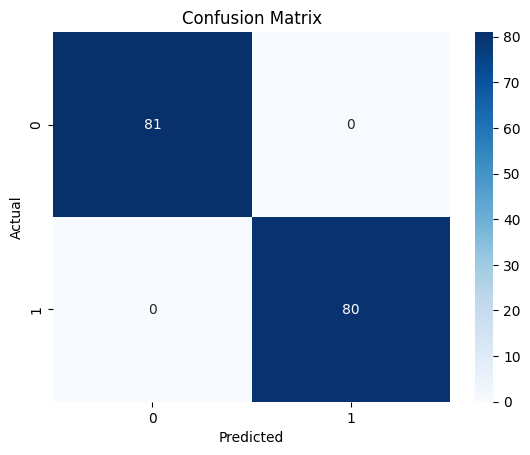

Train score: 0.9984447900466563
Test score: 1.0


In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

# ======================
# 1. LOAD DATA
# ======================
data = pd.read_csv(r"..\data\colon_cancer.csv", sep=";")

X = data.drop(["tissue_status", "id_sample"], axis=1)
y = data["tissue_status"].map({"normal": 1, "tumoral": 0})

# ======================
# 2. TRAIN / TEST SPLIT
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ======================
# 3. PIPELINE
# ======================
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# ======================
# 4. GRID SEARCH (robuste CV)
# ======================
param_grid = {
    "knn__n_neighbors": np.arange(3, 30, 2),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

# ======================
# 5. BEST MODEL
# ======================
best_model = grid.best_estimator_
print("Best params:", grid.best_params_)

# ======================
# 6. FINAL EVALUATION (IMPORTANT)
# ======================
y_pred = best_model.predict(X_test)

print("\nTEST SCORE:", best_model.score(X_test, y_test))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ======================
# 7. VISUALISATION
# ======================
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
print("Train score:", best_model.score(X_train, y_train))
print("Test score:", best_model.score(X_test, y_test))